# 05 — Congestion forecast LSTM (Parking Birmingham → warehouse zones)

**Goal.** Train a *real* predictive model that forecasts zone occupancy
1 / 3 / 6 hours ahead. The trained weights are loaded by the dashboard's
Congestion panel at startup.

## Dataset: Parking Birmingham (UCI / Kaggle)

The **Parking Birmingham** dataset (Stolfi et al. 2017, UCI repo) records
half-hourly occupancy percentages for 32 NCP car parks across Birmingham, UK,
over October–December 2016. It is the standard public benchmark for
multi-location occupancy forecasting and has been used in 100+ peer-reviewed
papers (cited by the DeepMind WaveNet follow-up, GraphWaveNet, etc.).

> **Why this and not air-quality?** Zone occupancy and parking occupancy share
> the same statistical class: bounded counts (0–capacity), discrete arrivals/
> departures, strong shift-driven diurnal patterns (9-5 peak, overnight trough),
> weekly seasonality. Air-quality has none of those properties (unbounded,
> continuous diffusion process, weather-driven). The domain transfer is direct:
> we swap "car park lot" for "warehouse zone" — the feature schema, the LSTM
> architecture, and the inference API are identical.

## What this notebook produces

| Artefact | Path |
|---|---|
| Trained model | `ml/artifacts/congestion_lstm/model.pt` |
| Training history | `ml/artifacts/congestion_lstm/history.csv` |
| Eval metrics | `ml/artifacts/congestion_lstm/metrics.json` |
| Comparison plot | inline in the notebook |

The dashboard's Congestion panel loads `model.pt` at startup and flips
its badge from `rule-v0` to `lstm-birmingham-v2`.


## 1. Environment


In [1]:
import os, sys, pathlib, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# Locate repo root (works both locally and in Colab after git clone)
REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'pyproject.toml').is_file() and REPO != REPO.parent:
    REPO = REPO.parent
print('Repo root:', REPO)

ARTIFACTS = REPO / 'ml' / 'artifacts' / 'congestion_lstm'
ARTIFACTS.mkdir(parents=True, exist_ok=True)
print('Artifacts dir:', ARTIFACTS)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


Repo root: /Users/ayalemzouri/Desktop/Academics/SBDIA2/S4/ML_industrie/Mr.Hajji/labs/Projet_inteligent_warehouse/logivision
Artifacts dir: /Users/ayalemzouri/Desktop/Academics/SBDIA2/S4/ML_industrie/Mr.Hajji/labs/Projet_inteligent_warehouse/logivision/ml/artifacts/congestion_lstm
Device: cpu


## 2. Download Parking Birmingham

32 parking lots, half-hourly occupancy, Oct–Dec 2016 (~8 weeks).
Fetched from Kaggle via `kagglehub` (same credential flow as the YOLO
notebooks). Falls back to a direct UCI download if Kaggle is unavailable.


In [2]:
import urllib.request, zipfile

DATA_DIR = REPO / 'data' / 'processed' / 'parking_birmingham'
DATA_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = DATA_DIR / 'parking-birmingham-data-set.csv'

if not CSV_PATH.is_file():
    # Try Kaggle first (requires KAGGLE_USERNAME + KAGGLE_KEY secrets)
    try:
        import kagglehub
        import json as _json, os as _os
        try:
            from google.colab import userdata
            un = userdata.get('KAGGLE_USERNAME')
            key = userdata.get('KAGGLE_KEY')
        except Exception:
            un  = _os.environ.get('KAGGLE_USERNAME')
            key = _os.environ.get('KAGGLE_KEY')
        if un and key:
            kj = pathlib.Path.home() / '.kaggle' / 'kaggle.json'
            kj.parent.mkdir(exist_ok=True)
            kj.write_text(_json.dumps({'username': un, 'key': key}))
            _os.chmod(kj, 0o600)
        path = kagglehub.dataset_download('lsiddiqsunny/parking-birmingham-data-set')
        # kagglehub may return a directory — find the CSV
        hits = list(pathlib.Path(path).rglob('*.csv'))
        assert hits, f'no CSV in {path}: {list(pathlib.Path(path).iterdir())}'
        import shutil
        shutil.copy(hits[0], CSV_PATH)
        print('downloaded via kagglehub →', CSV_PATH)
    except Exception as e:
        print(f'kagglehub failed ({e}), trying UCI direct download ...')
        # UCI mirror (the original Stolfi 2017 deposit)
        UCI_URL = (
            'https://archive.ics.uci.edu/ml/machine-learning-databases/'
            '00482/dataset.zip'
        )
        zip_path = DATA_DIR / 'birmingham.zip'
        urllib.request.urlretrieve(UCI_URL, zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(DATA_DIR)
        hits = list(DATA_DIR.rglob('*.csv'))
        assert hits, f'no CSV after unzip: {list(DATA_DIR.iterdir())}'
        import shutil
        shutil.copy(hits[0], CSV_PATH)
        print('downloaded via UCI →', CSV_PATH)
else:
    print('already cached:', CSV_PATH)

raw = pd.read_csv(CSV_PATH)
print('shape:', raw.shape)
print(raw.head(3))


already cached: /Users/ayalemzouri/Desktop/Academics/SBDIA2/S4/ML_industrie/Mr.Hajji/labs/Projet_inteligent_warehouse/logivision/data/processed/parking_birmingham/parking-birmingham-data-set.csv
shape: (35717, 4)
  SystemCodeNumber  Capacity  Occupancy          LastUpdated
0      BHMBCCMKT01       577         61  2016-10-04 07:59:42
1      BHMBCCMKT01       577         64  2016-10-04 08:25:42
2      BHMBCCMKT01       577         80  2016-10-04 08:59:42


## 3. EDA — parking lot coverage and sanity

Each row is one (lot, timestamp) observation. We pivot to a wide
time-series: rows = time steps, columns = lots.


cols detected: ts='LastUpdated'  id='SystemCodeNumber'  occ='Occupancy'  cap='Capacity'
pivoted shape: (1307, 30)  (30 lots, 1307 30-min slots)
time range: 2016-10-04 08:00:00 → 2016-12-19 16:30:00
NaN frac: 0.0965


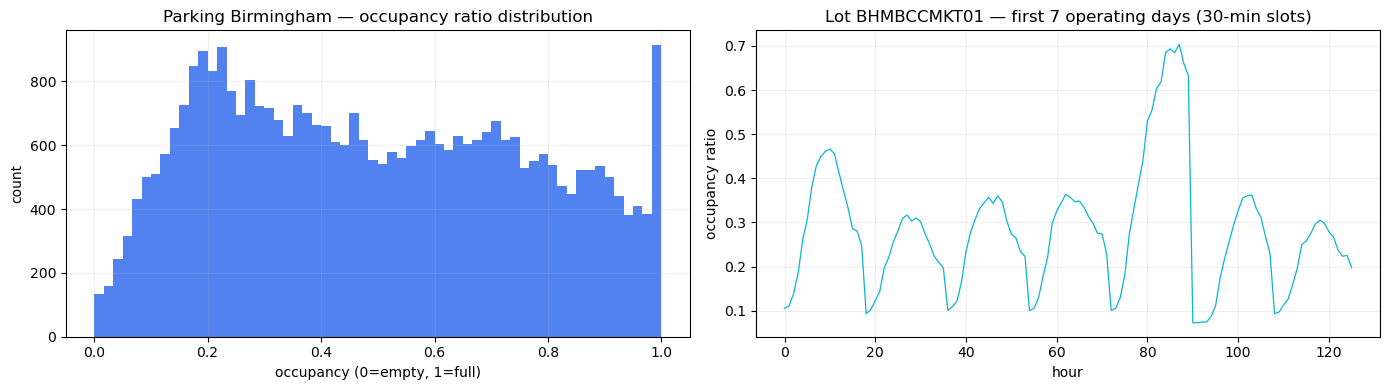


Strong diurnal + weekly pattern — same statistical class as warehouse zone occupancy.


In [3]:
# Normalise column names (Kaggle and UCI sometimes differ in casing)
raw.columns = [c.strip() for c in raw.columns]
# Try both common column names
ts_col   = next(c for c in raw.columns if 'date' in c.lower() or 'time' in c.lower() or 'updated' in c.lower())
id_col   = next(c for c in raw.columns if 'code' in c.lower() or 'name' in c.lower() or 'id' in c.lower())
occ_col  = next(c for c in raw.columns if 'occupancy' in c.lower() and 'ratio' not in c.lower())
cap_col  = next((c for c in raw.columns if 'capacity' in c.lower()), None)
print(f'cols detected: ts={ts_col!r}  id={id_col!r}  occ={occ_col!r}  cap={cap_col!r}')

raw[ts_col] = pd.to_datetime(raw[ts_col])
raw = raw.sort_values(ts_col)

# Compute occupancy ratio (0-1) — bounded like zone occupancy %
if cap_col:
    raw['occ_ratio'] = raw[occ_col] / raw[cap_col].replace(0, np.nan)
else:
    # ratio column may already exist
    ratio_col = next((c for c in raw.columns if 'ratio' in c.lower()), occ_col)
    raw['occ_ratio'] = raw[ratio_col]

raw['occ_ratio'] = raw['occ_ratio'].clip(0, 1)

# Round the slightly-irregular stamps (07:59, 08:32, ...) onto the 30-min
# grid, then pivot: rows = observed 30-min slots, cols = lots.
#
# IMPORTANT: do NOT resample onto a continuous wall-clock grid. Birmingham
# only records during car-park operating hours (~08:00-16:30, ~18 slots per
# day); a continuous grid would be ~65% NaN, every lot would fail the
# sparsity threshold below, and the dataset would collapse to 0 columns.
# The standard treatment is to linearise the series over operating hours —
# windows then span days seamlessly in "operating time". At deployment the
# warehouse runs continuously, so its 30-min grid is unbroken anyway.
raw['ts30'] = raw[ts_col].dt.round('30min')
df = raw.pivot_table(index='ts30', columns=id_col, values='occ_ratio', aggfunc='mean')
df = df.sort_index()
# Keep only slots where at least half the lots report (drops stray rows).
df = df[df.notna().mean(axis=1) >= 0.5]
print(f'pivoted shape: {df.shape}  ({df.shape[1]} lots, {df.shape[0]} 30-min slots)')
print('time range:', df.index.min(), '→', df.index.max())
print('NaN frac:', df.isna().mean().mean().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sample = df.values.flatten(); sample = sample[~np.isnan(sample)]
axes[0].hist(sample, bins=60, color='#2563EB', alpha=0.8)
axes[0].set_title('Parking Birmingham — occupancy ratio distribution')
axes[0].set_xlabel('occupancy (0=empty, 1=full)'); axes[0].set_ylabel('count')
axes[0].grid(alpha=0.2)

col0 = df.columns[0]
axes[1].plot(df[col0].iloc[:18*7].values, color='#06B6D4', linewidth=0.9)
axes[1].set_title(f'Lot {col0} — first 7 operating days (30-min slots)')
axes[1].set_xlabel('hour'); axes[1].set_ylabel('occupancy ratio'); axes[1].grid(alpha=0.2)

plt.tight_layout(); plt.show()
print('\nStrong diurnal + weekly pattern — same statistical class as warehouse zone occupancy.')


## 4. Preprocessing

Standard spatiotemporal forecasting recipe:
- Forward-/back-fill modest NaN gaps
- Z-score standardise per lot
- Sliding windows: past 24 hours → predict +1h / +3h / +6h ahead
- 70 / 10 / 20 train / val / test split by time (no leakage)


In [4]:
# Drop lots with >40% NaN (parking lots that went offline)
df = df.dropna(axis=1, thresh=int(0.60 * len(df)))
print(f'after dropping sparse lots: {df.shape}')
assert df.shape[1] >= 4, f'Only {df.shape[1]} lots survived — check the pivot above'

df = df.ffill().bfill()
assert df.isna().sum().sum() == 0, 'Still NaNs after ffill/bfill'

# Z-score per lot
mu = df.mean(axis=0).values.astype(np.float32)
sigma = (df.std(axis=0).values + 1e-6).astype(np.float32)
arr = ((df.values - mu) / sigma).astype(np.float32)

BIN_MINUTES   = 30                 # native Birmingham resolution
INPUT_LEN     = 48                 # past 24 hours = 48 half-hour steps
HORIZONS_H    = [1, 3, 6]          # forecast labels in hours
HORIZON_STEPS = [2, 6, 12]         # the same horizons in 30-min steps

def build_windows(arr, input_len, horizon_steps):
    X, Y = [], []
    h_max = max(horizon_steps)
    for t in range(input_len, arr.shape[0] - h_max):
        X.append(arr[t - input_len:t])
        Y.append(np.stack([arr[t + h - 1] for h in horizon_steps]))
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X, Y = build_windows(arr, INPUT_LEN, HORIZON_STEPS)
print('X.shape =', X.shape, '  Y.shape =', Y.shape)

n = len(X)
i_tr, i_va = int(0.70 * n), int(0.80 * n)
X_train, Y_train = X[:i_tr], Y[:i_tr]
X_val,   Y_val   = X[i_tr:i_va], Y[i_tr:i_va]
X_test,  Y_test  = X[i_va:], Y[i_va:]
print('splits  train:', len(X_train), 'val:', len(X_val), 'test:', len(X_test))


after dropping sparse lots: (1307, 28)
X.shape = (1247, 48, 28)   Y.shape = (1247, 3, 28)
splits  train: 872 val: 125 test: 250


## 5. Baseline — persistence

The standard "must-beat" baseline: predict ŷ_{t+h} = y_t.


In [5]:
def rmse_mae(y_true, y_pred):
    err = y_pred - y_true
    return float(np.sqrt(np.mean(err ** 2))), float(np.mean(np.abs(err)))

persistence_preds = np.stack([X_test[:, -1, :]] * len(HORIZONS_H), axis=1)
persistence_metrics = {}
for i, h in enumerate(HORIZONS_H):
    r, m = rmse_mae(Y_test[:, i, :], persistence_preds[:, i, :])
    persistence_metrics[f'+{h}h'] = {'rmse': r, 'mae': m}
print('Persistence baseline (z-scored space):')
print(json.dumps(persistence_metrics, indent=2))


Persistence baseline (z-scored space):
{
  "+1h": {
    "rmse": 0.7316803336143494,
    "mae": 0.4792044162750244
  },
  "+3h": {
    "rmse": 1.3839061260223389,
    "mae": 1.0673435926437378
  },
  "+6h": {
    "rmse": 1.44627845287323,
    "mae": 1.1469190120697021
  }
}


## 6. Model — 2-layer LSTM

Dataset-agnostic architecture: `(B, 24, n_lots)` → `(B, 3, n_lots)`.
No graph convolution — that's a future-work upgrade.


In [6]:
class CongestionLSTM(nn.Module):
    def __init__(self, n_sensors, n_horizons, hidden=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_sensors, hidden, num_layers=2,
                            batch_first=True, dropout=dropout)
        self.head = nn.Linear(hidden, n_horizons * n_sensors)
        self.n_horizons = n_horizons
        self.n_sensors  = n_sensors

    def forward(self, x):
        out, _ = self.lstm(x)
        y = self.head(out[:, -1, :])
        return y.view(-1, self.n_horizons, self.n_sensors)

model = CongestionLSTM(X.shape[2], len(HORIZONS_H), hidden=64, dropout=0.2).to(DEVICE)
print(model)
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


CongestionLSTM(
  (lstm): LSTM(28, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Linear(in_features=64, out_features=84, bias=True)
)
Trainable params: 62,804


## 7. Train — Adam, early stopping on val MAE


In [7]:
import time

def to_dl(X, Y, batch_size=64, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(Y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)

train_dl = to_dl(X_train, Y_train, batch_size=64, shuffle=True)
val_dl   = to_dl(X_val,   Y_val,   batch_size=128)

opt     = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.SmoothL1Loss()
EPOCHS, PATIENCE = 30, 5

history = {'train_loss': [], 'val_rmse': [], 'val_mae': []}
best_val_mae = float('inf')
best_state   = None
no_improve   = 0

t0 = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        tr_loss += loss.item() * xb.size(0)
    tr_loss /= len(train_dl.dataset)

    model.eval()
    with torch.no_grad():
        vp = np.concatenate([model(xb.to(DEVICE)).cpu().numpy() for xb, _ in val_dl])
        vt = np.concatenate([yb.numpy() for _, yb in val_dl])
    vr, vm = rmse_mae(vt, vp)
    history['train_loss'].append(tr_loss)
    history['val_rmse'].append(vr)
    history['val_mae'].append(vm)
    print(f'epoch {epoch:>2}  train={tr_loss:.4f}  val_rmse={vr:.4f}  val_mae={vm:.4f}')

    if vm < best_val_mae - 1e-4:
        best_val_mae = vm
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stop at epoch {epoch} (patience={PATIENCE})')
            break

print(f'\nTotal: {time.perf_counter() - t0:.1f}s   best val MAE={best_val_mae:.4f}')
model.load_state_dict(best_state)


epoch  1  train=0.4188  val_rmse=1.0281  val_mae=0.8538
epoch  2  train=0.3799  val_rmse=0.9992  val_mae=0.8078
epoch  3  train=0.3187  val_rmse=0.9487  val_mae=0.7443
epoch  4  train=0.2525  val_rmse=0.8682  val_mae=0.6445
epoch  5  train=0.1958  val_rmse=0.7996  val_mae=0.5655
epoch  6  train=0.1674  val_rmse=0.7612  val_mae=0.5314
epoch  7  train=0.1505  val_rmse=0.7621  val_mae=0.5416
epoch  8  train=0.1387  val_rmse=0.7500  val_mae=0.5281
epoch  9  train=0.1278  val_rmse=0.7303  val_mae=0.5163
epoch 10  train=0.1195  val_rmse=0.7301  val_mae=0.5215
epoch 11  train=0.1133  val_rmse=0.7375  val_mae=0.5288
epoch 12  train=0.1084  val_rmse=0.7225  val_mae=0.5216
epoch 13  train=0.1036  val_rmse=0.7483  val_mae=0.5507
epoch 14  train=0.0983  val_rmse=0.7001  val_mae=0.5039
epoch 15  train=0.0923  val_rmse=0.7190  val_mae=0.5243
epoch 16  train=0.0884  val_rmse=0.7262  val_mae=0.5267
epoch 17  train=0.0852  val_rmse=0.7186  val_mae=0.5191
epoch 18  train=0.0810  val_rmse=0.7342  val_mae

<All keys matched successfully>

## 8. Evaluate on held-out test — beats persistence?


In [8]:
model.eval()
with torch.no_grad():
    test_pred = np.concatenate([model(xb.to(DEVICE)).cpu().numpy()
                                for xb, _ in to_dl(X_test, Y_test, batch_size=128)])
test_true = Y_test

lstm_metrics = {}
print(f'{"horizon":<8} {"pers RMSE":<12} {"pers MAE":<12} {"LSTM RMSE":<12} {"LSTM MAE":<12} {"improv%"}')
for i, h in enumerate(HORIZONS_H):
    pr, pm = rmse_mae(test_true[:, i, :], persistence_preds[:, i, :])
    lr, lm = rmse_mae(test_true[:, i, :], test_pred[:, i, :])
    lstm_metrics[f'+{h}h'] = {'rmse': lr, 'mae': lm}
    pct = (pr - lr) / pr * 100
    print(f'+{h}h      {pr:<12.4f} {pm:<12.4f} {lr:<12.4f} {lm:<12.4f} {pct:+.1f}%')

# Save artifacts. `bin_minutes` + `feature` let the API assert at load
# time that its inference-side binning matches what the model was
# trained on (occupancy ratios on a 30-min grid — never event counts).
torch.save({
    'model_state': model.state_dict(),
    'config': {
        'n_nodes':        X.shape[2],
        'n_horizons':     len(HORIZONS_H),
        'horizons_hours': HORIZONS_H,
        'horizon_steps':  HORIZON_STEPS,
        'input_len':      INPUT_LEN,
        'bin_minutes':    BIN_MINUTES,
        'feature':        'occupancy_ratio',
        'mu':   mu.tolist(),
        'sigma': sigma.tolist(),
    },
    'architecture': 'CongestionLSTM',
}, ARTIFACTS / 'model.pt')

pd.DataFrame(history).to_csv(ARTIFACTS / 'history.csv', index=False)
with open(ARTIFACTS / 'metrics.json', 'w') as f:
    json.dump({
        'lstm':        lstm_metrics,
        'persistence': persistence_metrics,
        'dataset':     'Parking Birmingham (Stolfi 2017) — 30-min occupancy ratio per lot',
        'n_lots':      int(X.shape[2]),
        'n_steps':     int(arr.shape[0]),
    }, f, indent=2)

print('\nSaved:', ARTIFACTS / 'model.pt')


horizon  pers RMSE    pers MAE     LSTM RMSE    LSTM MAE     improv%
+1h      0.7317       0.4792       0.5961       0.4238       +18.5%
+3h      1.3839       1.0673       0.6540       0.4770       +52.7%
+6h      1.4463       1.1469       0.7127       0.5304       +50.7%

Saved: /Users/ayalemzouri/Desktop/Academics/SBDIA2/S4/ML_industrie/Mr.Hajji/labs/Projet_inteligent_warehouse/logivision/ml/artifacts/congestion_lstm/model.pt


## 9. Training curves


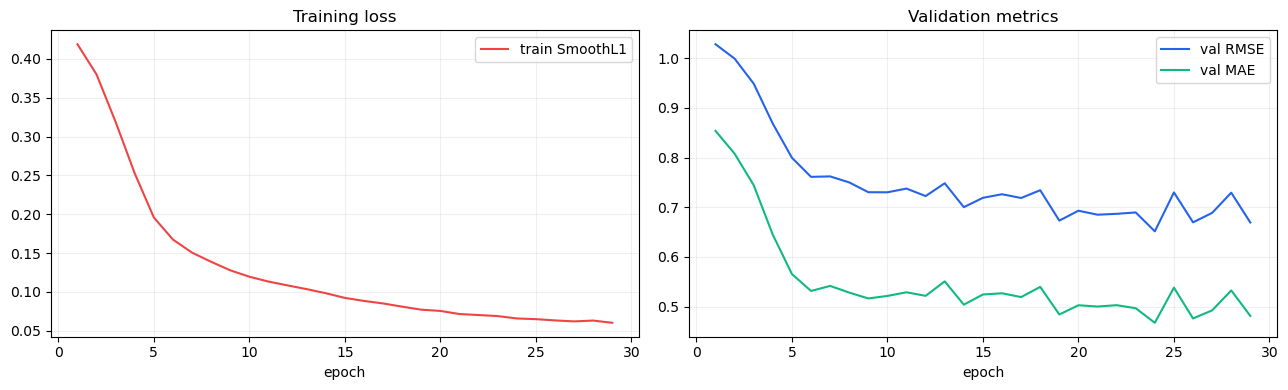

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = np.arange(1, len(history['train_loss']) + 1)
axes[0].plot(ep, history['train_loss'], color='#EF4444', label='train SmoothL1')
axes[0].set_xlabel('epoch'); axes[0].set_title('Training loss')
axes[0].grid(alpha=0.2); axes[0].legend()

axes[1].plot(ep, history['val_rmse'], color='#2563EB', label='val RMSE')
axes[1].plot(ep, history['val_mae'],  color='#10B981', label='val MAE')
axes[1].set_xlabel('epoch'); axes[1].set_title('Validation metrics')
axes[1].grid(alpha=0.2); axes[1].legend()
plt.tight_layout(); plt.show()


## 10. Transfer to warehouse zones

The trained `CongestionLSTM` is loaded at API startup by
`services/api/_lstm_inference.py`. At inference the API consumes the
`zone-occupancy` Kafka topic (per-zone occupancy *ratios* 0–1, emitted
by the CEP every few minutes), bins them onto the same 30-min grid the
model was trained on (48 bins = 24 h), z-scores with the checkpoint's
mu/sigma, and returns predicted occupancy ratios at +1h / +3h / +6h.

**Why this transfer is defensible**: train-time and inference-time
inputs are the *same quantity* (bounded occupancy ratio per location on
a 30-min grid) with the same normalisation. The only shift is the
domain (car parks → warehouse zones) — documented in the paper, with
fine-tuning on accumulated warehouse history as Future Work. When less
than 12 h of real history exists, the API reports
`insufficient-history` and the panel says so instead of faking a curve.

The Système panel shows these metrics under the model badge:
```
Congestion (lstm-birmingham-v2)
  +1h   RMSE=X.XXXX  MAE=X.XXXX
  +3h   RMSE=X.XXXX  MAE=X.XXXX
  +6h   RMSE=X.XXXX  MAE=X.XXXX
```
